<a href="https://colab.research.google.com/github/itsrohan888888/Razorpay-Buildathon-Project-VERDICTO/blob/main/flightdelaypredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/AduraX/Flight-Delay-Prediction/master/FlightDelayData1.csv"
df = pd.read_csv(url).sample(n=50000, random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split

df['IS_DELAYED'] = (df['ArrDelay'] > 15).astype(int)

df['SIN_HOUR'] = np.sin(2 * np.pi * (df['CRSDepTime'] // 100) / 24.0)
df['COS_HOUR'] = np.cos(2 * np.pi * (df['CRSDepTime'] // 100) / 24.0)

airport_traffic = df.groupby(['OriginAirportID', 'Month', 'DayofMonth']).size().reset_index(name='AIRPORT_DAILY_FLIGHTS')
df = df.merge(airport_traffic, on=['OriginAirportID', 'Month', 'DayofMonth'], how='left')

features_num = ['AIRPORT_DAILY_FLIGHTS', 'SIN_HOUR', 'COS_HOUR']
features_cat = ['Carrier', 'OriginAirportID', 'DestAirportID', 'DayOfWeek']

X = df[features_num + features_cat]
y = df['IS_DELAYED']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
!pip install catboost xgboost lightgbm optuna
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, f1_score

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', max_categories=20))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, features_num),
    ('cat', categorical_transformer, features_cat)
])

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}

results = []
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, probs),
        'F1-Score': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 21.7 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

all_model_metrics = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    probs = pipe.predict_proba(X_test)[:, 1]

    all_model_metrics.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, probs),
        'F1-Score': f1_score(y_test, preds),
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds)
    })

all_model_metrics_df = pd.DataFrame(all_model_metrics).sort_values(by='ROC-AUC', ascending=False)
display(all_model_metrics_df)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,ROC-AUC,F1-Score,Accuracy,Precision,Recall
4,CatBoost,0.681499,0.095079,0.7830,0.527778,0.052246
3,LightGBM,0.679522,0.052265,0.7824,0.526316,0.027498
2,XGBoost,0.674144,0.143136,0.7809,0.488000,0.083868
0,Logistic Regression,0.669108,0.021515,0.7817,0.489796,0.010999
1,Random Forest,0.618834,0.206918,0.7432,0.317235,0.153529


In [ ]:
import optuna

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'verbose': -1
    }

    model = LGBMClassifier(**params, random_state=42)
    model.fit(X_train_prep, y_train)
    preds_proba = model.predict_proba(X_test_prep)[:, 1]
    return roc_auc_score(y_test, preds_proba)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

print(study.best_value)
print(study.best_params)

[I 2026-09-07 19:51:49,583] A new study created in memory with name: no-name-756c9ed8-4f3e-4675-8ce3-c9a6e0138d28
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-09-07 19:51:52,091] Trial 0 finished with value: 0.6712211871403485 and parameters: {'n_estimators': 264, 'max_depth': 9, 'learning_rate': 0.08969417513689858, 'num_leaves': 66}. Best is trial 0 with value: 0.6712211871403485.
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-09-07 19:51:54,105] Trial 1 finished with value: 0.6760934600849435 and parameters: {'n_estimators': 292, 'max_depth': 7, 'learning_rate': 0.0632018901308066, 'num_leaves': 45}. Best is trial 1 with value: 0.6760934600849435.
/usr/local/lib/python3.13/dist-packag

0.6803244539675416
{'n_estimators': 285, 'max_depth': 10, 'learning_rate': 0.02907366448346731, 'num_leaves': 26}


In [ ]:
def catboost_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'verbose': 0,
        'random_seed': 42
    }

    model = CatBoostClassifier(**params)
    model.fit(X_train_prep, y_train, early_stopping_rounds=50, eval_set=[(X_test_prep, y_test)])
    preds_proba = model.predict_proba(X_test_prep)[:, 1]
    return roc_auc_score(y_test, preds_proba)

catboost_study = optuna.create_study(direction='maximize')
catboost_study.optimize(catboost_objective, n_trials=20)

print("CatBoost Best ROC-AUC:", catboost_study.best_value)
print("CatBoost Best Params:", catboost_study.best_params)

[I 2026-09-07 21:02:54,601] A new study created in memory with name: no-name-f5b6a168-0f81-4744-9eb6-5672cb37f7e6
[I 2026-09-07 21:03:02,870] Trial 0 finished with value: 0.6786566125458676 and parameters: {'iterations': 306, 'depth': 10, 'learning_rate': 0.07289780997104084, 'l2_leaf_reg': 8.846514453590354}. Best is trial 0 with value: 0.6786566125458676.
[I 2026-09-07 21:03:05,298] Trial 1 finished with value: 0.6750977321131826 and parameters: {'iterations': 132, 'depth': 8, 'learning_rate': 0.11577608516799394, 'l2_leaf_reg': 0.012358627443027877}. Best is trial 0 with value: 0.6786566125458676.
[I 2026-09-07 21:03:14,385] Trial 2 finished with value: 0.6755474979711442 and parameters: {'iterations': 363, 'depth': 9, 'learning_rate': 0.01505111834968463, 'l2_leaf_reg': 0.10199307095047878}. Best is trial 0 with value: 0.6786566125458676.
[I 2026-09-07 21:03:22,192] Trial 3 finished with value: 0.6756329666737715 and parameters: {'iterations': 480, 'depth': 7, 'learning_rate': 0.01

CatBoost Best ROC-AUC: 0.6830536197109353
CatBoost Best Params: {'iterations': 472, 'depth': 8, 'learning_rate': 0.02771391199088429, 'l2_leaf_reg': 9.862828080129699}


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Get best parameters from Optuna studies
lgbm_best_params = study.best_params
lgbm_best_params['verbose'] = -1

catboost_best_params = catboost_study.best_params
catboost_best_params['verbose'] = 0 # Ensure verbose is set to 0 for CatBoost for clean output
catboost_best_params['random_seed'] = 42

# Create fine-tuned models
fine_tuned_lgbm = LGBMClassifier(**lgbm_best_params)
fine_tuned_catboost = CatBoostClassifier(**catboost_best_params)

# Prepare a list to store metrics for comparison
fine_tuned_results = []

# Evaluate fine-tuned LightGBM
pipeline_lgbm = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', fine_tuned_lgbm)])
pipeline_lgbm.fit(X_train, y_train)
preds_lgbm = pipeline_lgbm.predict(X_test)
probs_lgbm = pipeline_lgbm.predict_proba(X_test)[:, 1]
fine_tuned_results.append({
    'Model': 'LightGBM (Fine-tuned)',
    'ROC-AUC': roc_auc_score(y_test, probs_lgbm),
    'F1-Score': f1_score(y_test, preds_lgbm),
    'Accuracy': accuracy_score(y_test, preds_lgbm),
    'Precision': precision_score(y_test, preds_lgbm),
    'Recall': recall_score(y_test, preds_lgbm)
})

# Evaluate fine-tuned CatBoost
pipeline_catboost = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', fine_tuned_catboost)])
pipeline_catboost.fit(X_train, y_train)
preds_catboost = pipeline_catboost.predict(X_test)
probs_catboost = pipeline_catboost.predict_proba(X_test)[:, 1]
fine_tuned_results.append({
    'Model': 'CatBoost (Fine-tuned)',
    'ROC-AUC': roc_auc_score(y_test, probs_catboost),
    'F1-Score': f1_score(y_test, preds_catboost),
    'Accuracy': accuracy_score(y_test, preds_catboost),
    'Precision': precision_score(y_test, preds_catboost),
    'Recall': recall_score(y_test, preds_catboost)
})

# Convert to DataFrame and display
fine_tuned_df = pd.DataFrame(fine_tuned_results)

# Combine with original results for a full comparison
full_comparison_df = pd.concat([all_model_metrics_df, fine_tuned_df], ignore_index=True).sort_values(by='ROC-AUC', ascending=False)
display(full_comparison_df)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,ROC-AUC,F1-Score,Accuracy,Precision,Recall
6,CatBoost (Fine-tuned),0.683048,0.028584,0.7825,0.561404,0.014665
0,CatBoost,0.681499,0.095079,0.7830,0.527778,0.052246
5,LightGBM (Fine-tuned),0.680324,0.042216,0.7822,0.521739,0.021998
1,LightGBM,0.679522,0.052265,0.7824,0.526316,0.027498
2,XGBoost,0.674144,0.143136,0.7809,0.488000,0.083868
3,Logistic Regression,0.669108,0.021515,0.7817,0.489796,0.010999
4,Random Forest,0.618834,0.206918,0.7432,0.317235,0.153529


In [ ]:
from sklearn.ensemble import VotingClassifier

# Create a pipeline for each fine-tuned model
pipeline_lgbm_tuned = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', fine_tuned_lgbm)])
pipeline_catboost_tuned = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', fine_tuned_catboost)])

# Create the VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ('lgbm', pipeline_lgbm_tuned),
        ('catboost', pipeline_catboost_tuned)
    ],
    voting='soft', # Use 'soft' for probability predictions
    weights=[1, 1], # You can adjust weights based on individual model performance or further tune
    n_jobs=-1 # Use all available cores
)

# Fit the voting classifier
voting_clf.fit(X_train, y_train)

# Make predictions
voting_preds = voting_clf.predict(X_test)
voting_probs = voting_clf.predict_proba(X_test)[:, 1]

# Calculate metrics for the VotingClassifier
voting_metrics = {
    'Model': 'CatBoost + LightGBM (Ensemble)',
    'ROC-AUC': roc_auc_score(y_test, voting_probs),
    'F1-Score': f1_score(y_test, voting_preds),
    'Accuracy': accuracy_score(y_test, voting_preds),
    'Precision': precision_score(y_test, voting_preds),
    'Recall': recall_score(y_test, voting_preds)
}

# Add the ensemble results to the full comparison DataFrame and display
full_comparison_df = pd.concat([full_comparison_df, pd.DataFrame([voting_metrics])], ignore_index=True).sort_values(by='ROC-AUC', ascending=False)
display(full_comparison_df)


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,ROC-AUC,F1-Score,Accuracy,Precision,Recall
0,CatBoost (Fine-tuned),0.683048,0.028584,0.7825,0.561404,0.014665
7,CatBoost + LightGBM (Ensemble),0.682943,0.032014,0.7823,0.537313,0.016499
1,CatBoost,0.681499,0.095079,0.7830,0.527778,0.052246
2,LightGBM (Fine-tuned),0.680324,0.042216,0.7822,0.521739,0.021998
3,LightGBM,0.679522,0.052265,0.7824,0.526316,0.027498
4,XGBoost,0.674144,0.143136,0.7809,0.488000,0.083868
5,Logistic Regression,0.669108,0.021515,0.7817,0.489796,0.010999
6,Random Forest,0.618834,0.206918,0.7432,0.317235,0.153529


In [ ]:
models_to_compare = [
    'CatBoost + LightGBM (Ensemble)',
    'CatBoost (Fine-tuned)',
    'LightGBM (Fine-tuned)'
]

ensemble_comparison_df = full_comparison_df[full_comparison_df['Model'].isin(models_to_compare)].sort_values(by='ROC-AUC', ascending=False)
display(ensemble_comparison_df)

,Model,ROC-AUC,F1-Score,Accuracy,Precision,Recall
0,CatBoost (Fine-tuned),0.683048,0.028584,0.7825,0.561404,0.014665
7,CatBoost + LightGBM (Ensemble),0.682943,0.032014,0.7823,0.537313,0.016499
2,LightGBM (Fine-tuned),0.680324,0.042216,0.7822,0.521739,0.021998


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define a range of weights to try for the VotingClassifier
# Weights should sum to 1 for soft voting with two models
param_grid = {
    'weights': [[w, 1-w] for w in np.arange(0.1, 1.0, 0.1)]
}

# Re-create the VotingClassifier without initial weights for GridSearchCV
voting_clf_tuned_weights = VotingClassifier(
    estimators=[
        ('lgbm', pipeline_lgbm_tuned),
        ('catboost', pipeline_catboost_tuned)
    ],
    voting='soft',
    n_jobs=-1
)

# Perform GridSearchCV to find the best weights
grid_search = GridSearchCV(estimator=voting_clf_tuned_weights, param_grid=param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_voting_clf = grid_search.best_estimator_
best_weights = grid_search.best_params_['weights']

# Evaluate the best ensemble with tuned weights
best_voting_preds = best_voting_clf.predict(X_test)
best_voting_probs = best_voting_clf.predict_proba(X_test)[:, 1]

# Calculate metrics for the VotingClassifier with tuned weights
best_voting_metrics = {
    'Model': f'CatBoost + LightGBM (Ensemble - Tuned Weights {best_weights})',
    'ROC-AUC': roc_auc_score(y_test, best_voting_probs),
    'F1-Score': f1_score(y_test, best_voting_preds),
    'Accuracy': accuracy_score(y_test, best_voting_preds),
    'Precision': precision_score(y_test, best_voting_preds),
    'Recall': recall_score(y_test, best_voting_preds)
}

# Add the new ensemble results to the full comparison DataFrame and display
full_comparison_df = pd.concat([full_comparison_df, pd.DataFrame([best_voting_metrics])], ignore_index=True).sort_values(by='ROC-AUC', ascending=False)
display(full_comparison_df)

print(f"Best ensemble ROC-AUC with tuned weights: {grid_search.best_score_:.4f}")
print(f"Best weights: {best_weights}")

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,ROC-AUC,F1-Score,Accuracy,Precision,Recall
8,CatBoost + LightGBM (Ensemble - Tuned Weights ...,0.683300,0.030303,0.7824,0.548387,0.015582
0,CatBoost (Fine-tuned),0.683048,0.028584,0.7825,0.561404,0.014665
1,CatBoost + LightGBM (Ensemble),0.682943,0.032014,0.7823,0.537313,0.016499
2,CatBoost,0.681499,0.095079,0.7830,0.527778,0.052246
3,LightGBM (Fine-tuned),0.680324,0.042216,0.7822,0.521739,0.021998
4,LightGBM,0.679522,0.052265,0.7824,0.526316,0.027498
5,XGBoost,0.674144,0.143136,0.7809,0.488000,0.083868
6,Logistic Regression,0.669108,0.021515,0.7817,0.489796,0.010999
7,Random Forest,0.618834,0.206918,0.7432,0.317235,0.153529


Best ensemble ROC-AUC with tuned weights: 0.6710
Best weights: [np.float64(0.30000000000000004), np.float64(0.7)]


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


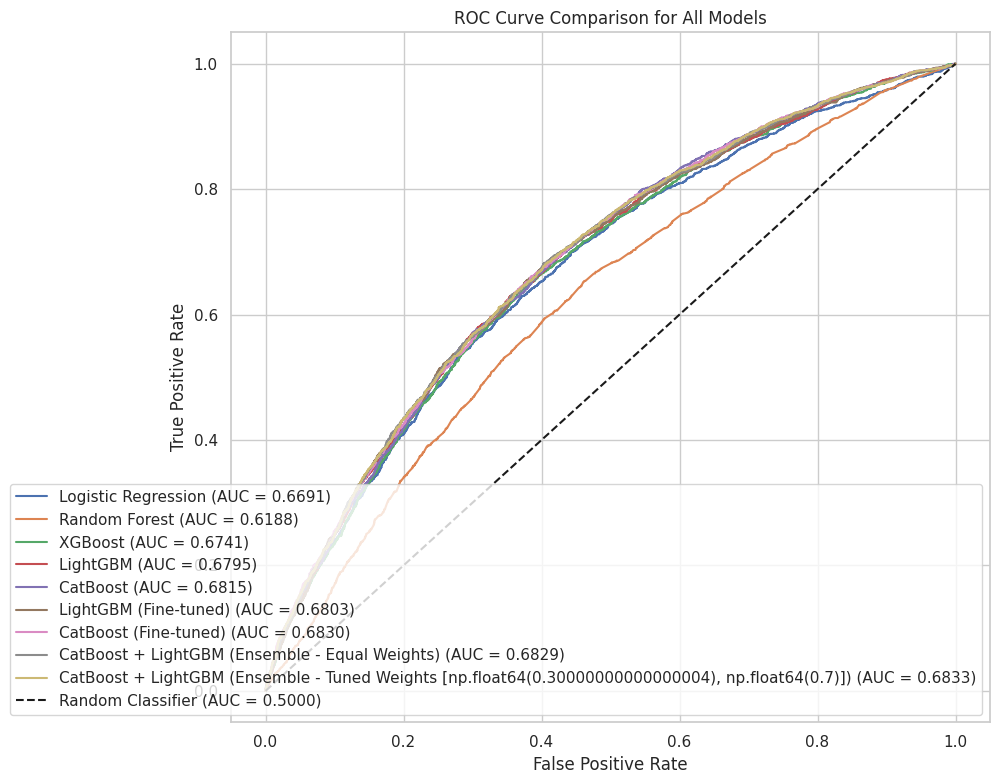

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

# Dictionary to store model probabilities for plotting
model_probs = {}

# 1. Initial Models (re-fit pipelines to get probabilities)
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]
    model_probs[name] = probs

# 2. Fine-tuned LightGBM
model_probs['LightGBM (Fine-tuned)'] = pipeline_lgbm.predict_proba(X_test)[:, 1]

# 3. Fine-tuned CatBoost
model_probs['CatBoost (Fine-tuned)'] = pipeline_catboost.predict_proba(X_test)[:, 1]

# 4. Equal-weighted Ensemble
model_probs['CatBoost + LightGBM (Ensemble - Equal Weights)'] = voting_clf.predict_proba(X_test)[:, 1]

# 5. Tuned-weighted Ensemble
model_probs[f'CatBoost + LightGBM (Ensemble - Tuned Weights {best_weights})'] = best_voting_clf.predict_proba(X_test)[:, 1]

# Plotting all ROC curves
for name, probs in model_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_score = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)') # Diagonal random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import joblib

best_params = study.best_params
best_params['verbose'] = -1

final_model = LGBMClassifier(**best_params, random_state=42)
final_model.fit(X_train_prep, y_train)

joblib.dump(final_model, 'flight_delay_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

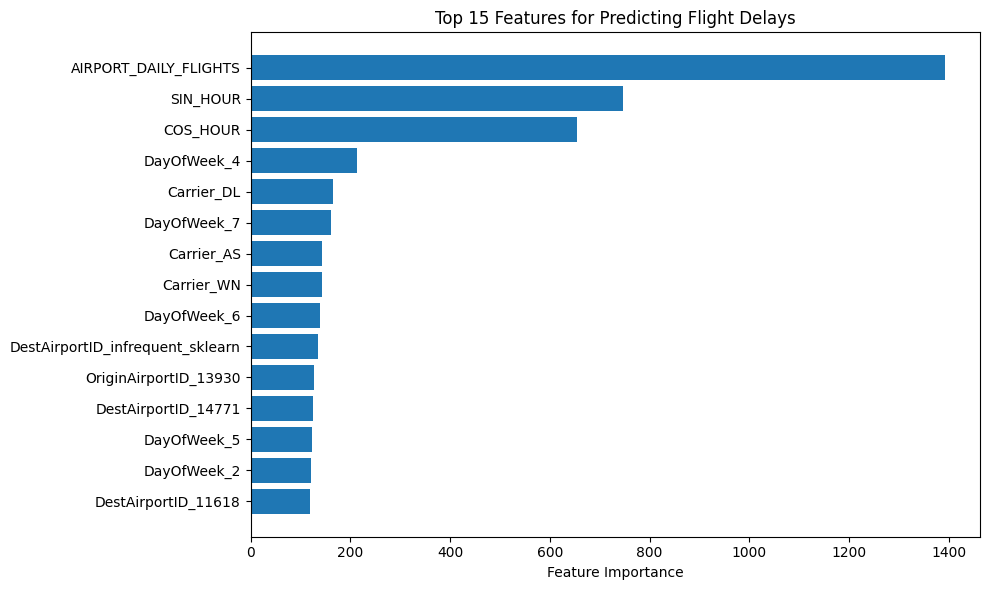

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(features_cat)
all_feature_names = features_num + list(cat_feature_names)

importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:15][::-1], importance_df['Importance'][:15][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features for Predicting Flight Delays')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

In [ ]:
import joblib
import pandas as pd

loaded_model = joblib.load('flight_delay_model.pkl')
loaded_preprocessor = joblib.load('preprocessor.pkl')

new_flight = pd.DataFrame([{
    'AIRPORT_DAILY_FLIGHTS': 120,
    'SIN_HOUR': -0.7071,
    'COS_HOUR': 0.7071,
    'Carrier': 'AA',
    'OriginAirportID': 12892,
    'DestAirportID': 10397,
    'DayOfWeek': 5
}])

processed_input = loaded_preprocessor.transform(new_flight)
delay_probability = loaded_model.predict_proba(processed_input)[0][1]
delay_prediction = loaded_model.predict(processed_input)[0]

print(f"Delay Probability: {delay_probability:.2%}")
print(f"Is Delayed (>15 mins): {bool(delay_prediction)}")

Delay Probability: 34.22%
Is Delayed (>15 mins): False


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


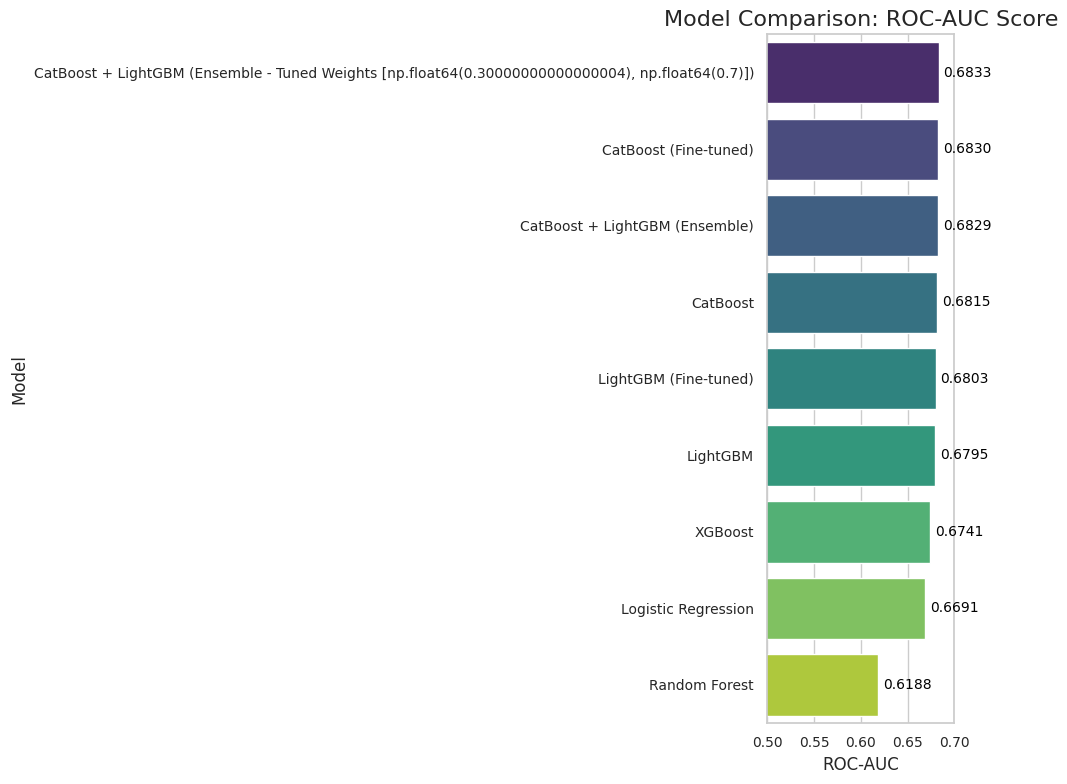

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

# Sort by ROC-AUC for consistent ordering
display_df = full_comparison_df.sort_values(by='ROC-AUC', ascending=False)

sns.barplot(data=display_df, x='ROC-AUC', y='Model', palette='viridis', hue='Model', legend=False)
plt.title('Model Comparison: ROC-AUC Score', fontsize=16)
plt.xlabel('ROC-AUC', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0.5, 0.7)
plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)

for p in plt.gca().patches:
    width = p.get_width()
    plt.gca().annotate(f"{width:.4f}",
                     (width + 0.005, p.get_y() + p.get_height() / 2.),
                     ha='left', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 600x500 with 0 Axes>

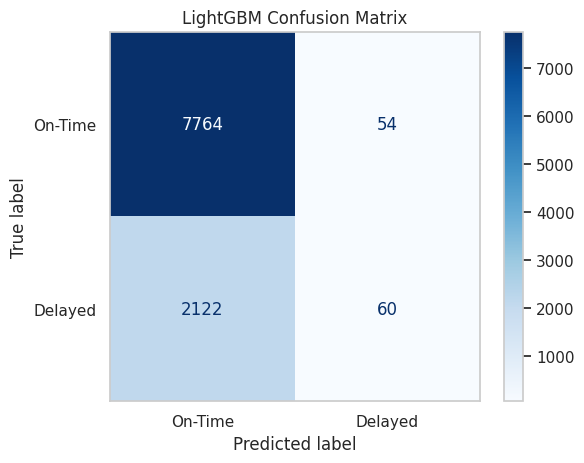

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

lgbm_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', models['LightGBM'])])
lgbm_pipe.fit(X_train, y_train)
y_pred = lgbm_pipe.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['On-Time', 'Delayed'])

plt.figure(figsize=(6, 5))
disp.plot(cmap='Blues', values_format='d')
plt.title('LightGBM Confusion Matrix')
plt.grid(False)
plt.show()